In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication-quality figure formatting
sns.set_theme(style="ticks", font_scale=1.05)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 1. Load cell line metadata
metadata_path = "../data/raw/Model.csv"
meta_df = pd.read_csv(metadata_path, low_memory=False)

# Normalize Model ID column
id_col = 'DepMap_ID' if 'DepMap_ID' in meta_df.columns else meta_df.columns[0]
meta_df = meta_df.rename(columns={id_col: 'ModelID'})

# 2. Identify the exact CDK7 feature column in the CRISPR matrix
crispr_path = "../data/raw/CRISPRGeneEffect.csv"
header_df = pd.read_csv(crispr_path, nrows=0)
cdk7_col = [c for c in header_df.columns if "CDK7" in c][0]
first_col = header_df.columns[0]
print(f"Target CDK7 feature column: {cdk7_col}")

# 3. Memory-efficient load: extract only cell identifiers and CDK7 scores
cdk7_df = pd.read_csv(crispr_path, usecols=[first_col, cdk7_col])
cdk7_df = cdk7_df.rename(columns={first_col: 'ModelID', cdk7_col: 'CDK7_Chronos_Score'})

# 4. Inner merge dependency scores with clinical/lineage annotations
merged_df = pd.merge(cdk7_df, meta_df, on='ModelID', how='inner')
merged_df = merged_df.dropna(subset=['lineage', 'CDK7_Chronos_Score'])

print(f"Annotated cell lines with CDK7 scores: {len(merged_df)}")
print(f"Unique cancer lineages represented: {merged_df['lineage'].nunique()}")
merged_df[['ModelID', 'lineage', 'primary_disease', 'CDK7_Chronos_Score']].head()

Target CDK7 feature column: CDK7 (1022)
Annotated cell lines with CDK7 scores: 1766
Unique cancer lineages represented: 30


,ModelID,lineage,primary_disease,CDK7_Chronos_Score
0,ACH-000267,lymphocyte,Lymphoma,0.984938
1,ACH-001408,urinary_tract,Bladder Cancer,0.623595
2,ACH-000617,ovary,Ovarian Cancer,0.797398
3,ACH-002123,lung,Lung Cancer,1.002826
4,ACH-000519,blood,Leukemia,1.001613


In [3]:
# 1. Filter lineages with sufficient sample size (n >= 15 for robust statistical power)
lineage_counts = merged_df['lineage'].value_counts()
robust_lineages = lineage_counts[lineage_counts >= 15].index

filtered_df = merged_df[merged_df['lineage'].isin(robust_lineages)].copy()

# 2. Compute median dependency, IQR, and sample size per lineage
summary_stats = (
    filtered_df.groupby('lineage')['CDK7_Chronos_Score']
    .agg(
        median_score='median',
        mean_score='mean',
        iqr=lambda x: np.percentile(x, 75) - np.percentile(x, 25),
        sample_count='count'
    )
    .sort_values('median_score', ascending=False)
    .reset_index()
)

print("Top 10 Lineages Ranked by CDK7 Vulnerability (Median Score):")
print(summary_stats.head(10).to_string(index=False))

Top 10 Lineages Ranked by CDK7 Vulnerability (Median Score):
               lineage  median_score  mean_score      iqr  sample_count
              pancreas      1.047808    1.032726 0.130848            60
                cervix      1.036013    1.010877 0.112862            24
central_nervous_system      1.032730    1.020580 0.143403           105
           plasma_cell      1.028216    1.027664 0.095077            35
                kidney      1.024194    1.021621 0.142398            60
                uterus      1.023455    1.036400 0.104678            40
                 liver      1.012238    1.001742 0.166855            26
               thyroid      1.011164    0.978440 0.148480            21
           soft_tissue      1.009398    1.016408 0.069391            64
                 ovary      1.004306    0.957666 0.184657            73


/tmp/ipykernel_20975/835111169.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


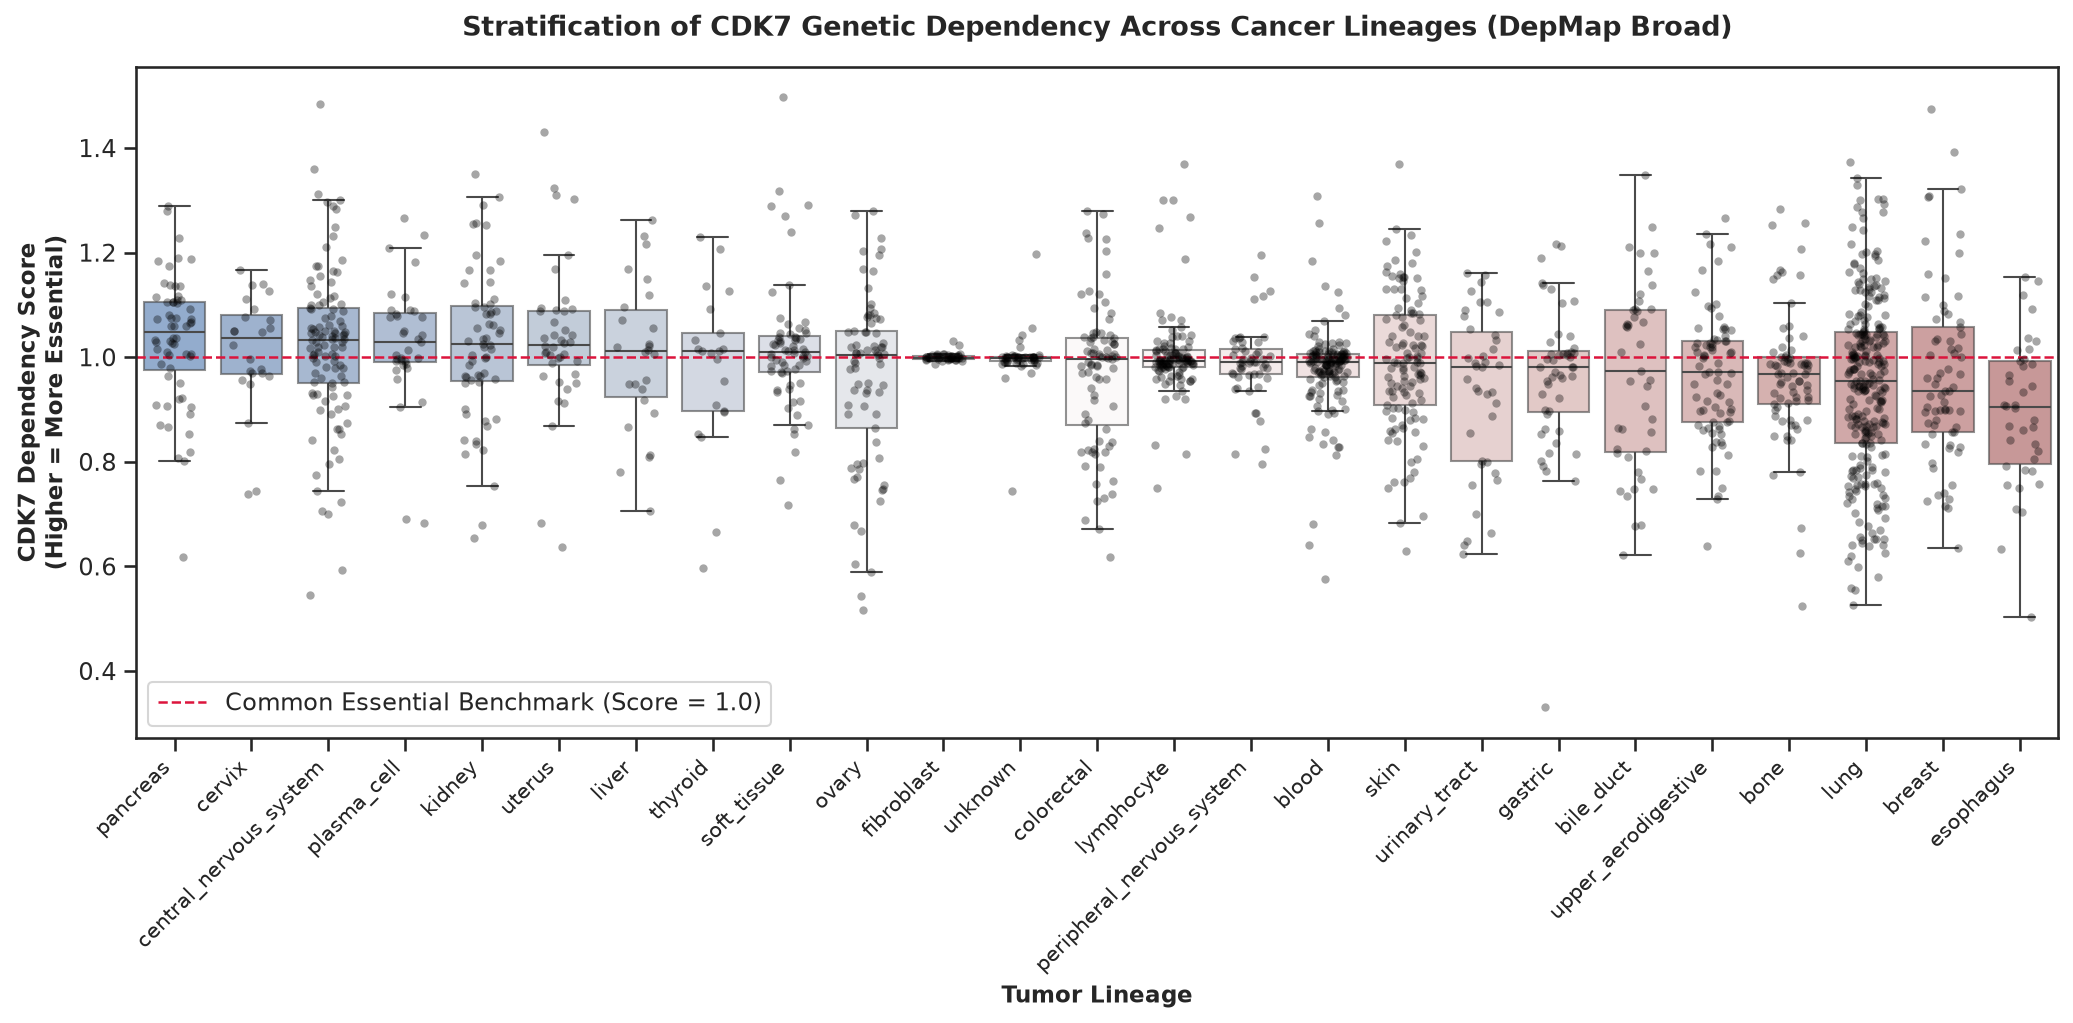

Figure saved to: ../figures/01_cdk7_lineage_distribution.png


In [4]:
# Create output directory for figures if it doesn't exist
os.makedirs("../figures", exist_ok=True)

# Order lineages by descending median dependency
ordered_lineages = summary_stats['lineage'].tolist()

plt.figure(figsize=(14, 7))

# 1. Base boxplot showing median and IQR
ax = sns.boxplot(
    data=filtered_df,
    x='lineage',
    y='CDK7_Chronos_Score',
    order=ordered_lineages,
    palette="vlag",
    boxprops=dict(alpha=0.6),
    showfliers=False
)

# 2. Overlay individual cell line jitter points
sns.stripplot(
    data=filtered_df,
    x='lineage',
    y='CDK7_Chronos_Score',
    order=ordered_lineages,
    color='black',
    alpha=0.35,
    size=4,
    jitter=0.25
)

# Benchmark reference line: common essential threshold (1.0)
plt.axhline(1.0, color='crimson', linestyle='--', linewidth=1.2, label='Common Essential Benchmark (Score = 1.0)')

plt.title('Stratification of CDK7 Genetic Dependency Across Cancer Lineages (DepMap Broad)', fontsize=13, weight='bold', pad=15)
plt.xlabel('Tumor Lineage', fontsize=11, weight='bold')
plt.ylabel('CDK7 Dependency Score\n(Higher = More Essential)', fontsize=11, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(frameon=True, loc='lower left')
plt.tight_layout()

# Save publication figure
fig_path = "../figures/01_cdk7_lineage_distribution.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Figure saved to: {fig_path}")

In [5]:
from statsmodels.stats.multitest import multipletests

results = []
all_scores = filtered_df['CDK7_Chronos_Score'].values

for lineage in ordered_lineages:
    lineage_scores = filtered_df[filtered_df['lineage'] == lineage]['CDK7_Chronos_Score'].values
    other_scores = filtered_df[filtered_df['lineage'] != lineage]['CDK7_Chronos_Score'].values
    
    # Non-parametric two-sided comparison
    stat, pval = stats.mannwhitneyu(lineage_scores, other_scores, alternative='two-sided')
    
    # Effect size: median difference
    delta_median = np.median(lineage_scores) - np.median(other_scores)
    
    results.append({
        'lineage': lineage,
        'n': len(lineage_scores),
        'median': np.median(lineage_scores),
        'delta_median': delta_median,
        'p_value': pval
    })

stat_df = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction
reject, q_values, _, _ = multipletests(stat_df['p_value'], method='fdr_bh')
stat_df['fdr_q_value'] = q_values
stat_df['significant'] = reject

# Display top findings sorted by significance
stat_df = stat_df.sort_values('p_value').reset_index(drop=True)
stat_df.head(10)

ModuleNotFoundError: No module named 'statsmodels'

In [6]:
from statsmodels.stats.multitest import multipletests

results = []
all_scores = filtered_df['CDK7_Chronos_Score'].values

for lineage in ordered_lineages:
    lineage_scores = filtered_df[filtered_df['lineage'] == lineage]['CDK7_Chronos_Score'].values
    other_scores = filtered_df[filtered_df['lineage'] != lineage]['CDK7_Chronos_Score'].values
    
    # Non-parametric two-sided comparison
    stat, pval = stats.mannwhitneyu(lineage_scores, other_scores, alternative='two-sided')
    
    # Effect size: median difference
    delta_median = np.median(lineage_scores) - np.median(other_scores)
    
    results.append({
        'lineage': lineage,
        'n': len(lineage_scores),
        'median': np.median(lineage_scores),
        'delta_median': delta_median,
        'p_value': pval
    })

stat_df = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction
reject, q_values, _, _ = multipletests(stat_df['p_value'], method='fdr_bh')
stat_df['fdr_q_value'] = q_values
stat_df['significant'] = reject

# Display top findings sorted by significance
stat_df = stat_df.sort_values('p_value').reset_index(drop=True)
stat_df.head(10)

,lineage,n,median,delta_median,p_value,fdr_q_value,significant
0,lung,265,0.953568,-0.042759,0.000086,0.001130,True
1,esophagus,38,0.904110,-0.091106,0.000093,0.001130,True
2,pancreas,60,1.047808,0.054644,0.000136,0.001130,True
3,central_nervous_system,105,1.032730,0.039680,0.000437,0.002732,True
4,uterus,40,1.023455,0.029824,0.006348,0.031742,True
5,plasma_cell,35,1.028216,0.034435,0.010127,0.042195,True
6,kidney,60,1.024194,0.030413,0.018904,0.067513,False
7,bone,73,0.967789,-0.028018,0.032630,0.101970,False
8,soft_tissue,64,1.009398,0.015683,0.065866,0.172326,False
9,breast,69,0.935748,-0.059163,0.068930,0.172326,False


In [7]:
import os

# Create processed data directory
os.makedirs("../data/processed", exist_ok=True)

# Save the full statistical ranking
stat_output_path = "../data/processed/cdk7_lineage_statistics.csv"
stat_df.to_csv(stat_output_path, index=False)

print(f"Statistical table saved to: {stat_output_path}")

Statistical table saved to: ../data/processed/cdk7_lineage_statistics.csv
